In [4]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [5]:
from DNAnet.data.data_models.synthetic_image import SyntheticImage
from DNAnet.data.data_models.dna_models import Panel

from DNAnet.evaluation.visualizations import plot_profile, plot_profile_markers


import matplotlib.pyplot as plt
import os
import numpy as np

# Create Synthetic Image

In [6]:
base_dir = "/Users/amarmesic/Documents/tudelft/thesis/dna/generated_epgs/fixed_ratios_all_loci_thresh_15"
npy_files = [f for f in os.listdir(base_dir) if f.endswith('.npy')]

dataset_file = f"{base_dir}/epgs/epg_configID1_sample_0001_N2_250_250_bb_rep1_deg1.npy"
reference_genotype_path = f"{base_dir}/reference_genotypes"
epg_to_genotypes_mapping_path = f"{base_dir}/alleles_to_genotypes_mapping.csv"
gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"

image = SyntheticImage(
    path=dataset_file,
    panel=Panel(gf_panel_path),
    reference_genotype_path=reference_genotype_path,
    epg_to_genotypes_mapping_path=epg_to_genotypes_mapping_path,
    size_standard="SYNTHETIC_GENESCAN_600_LIZ",
    include_size_standard=True,
)

print(image.data.shape)
print(image.annotation.image.sum())

(6, 4096, 1)
624


### Visualization

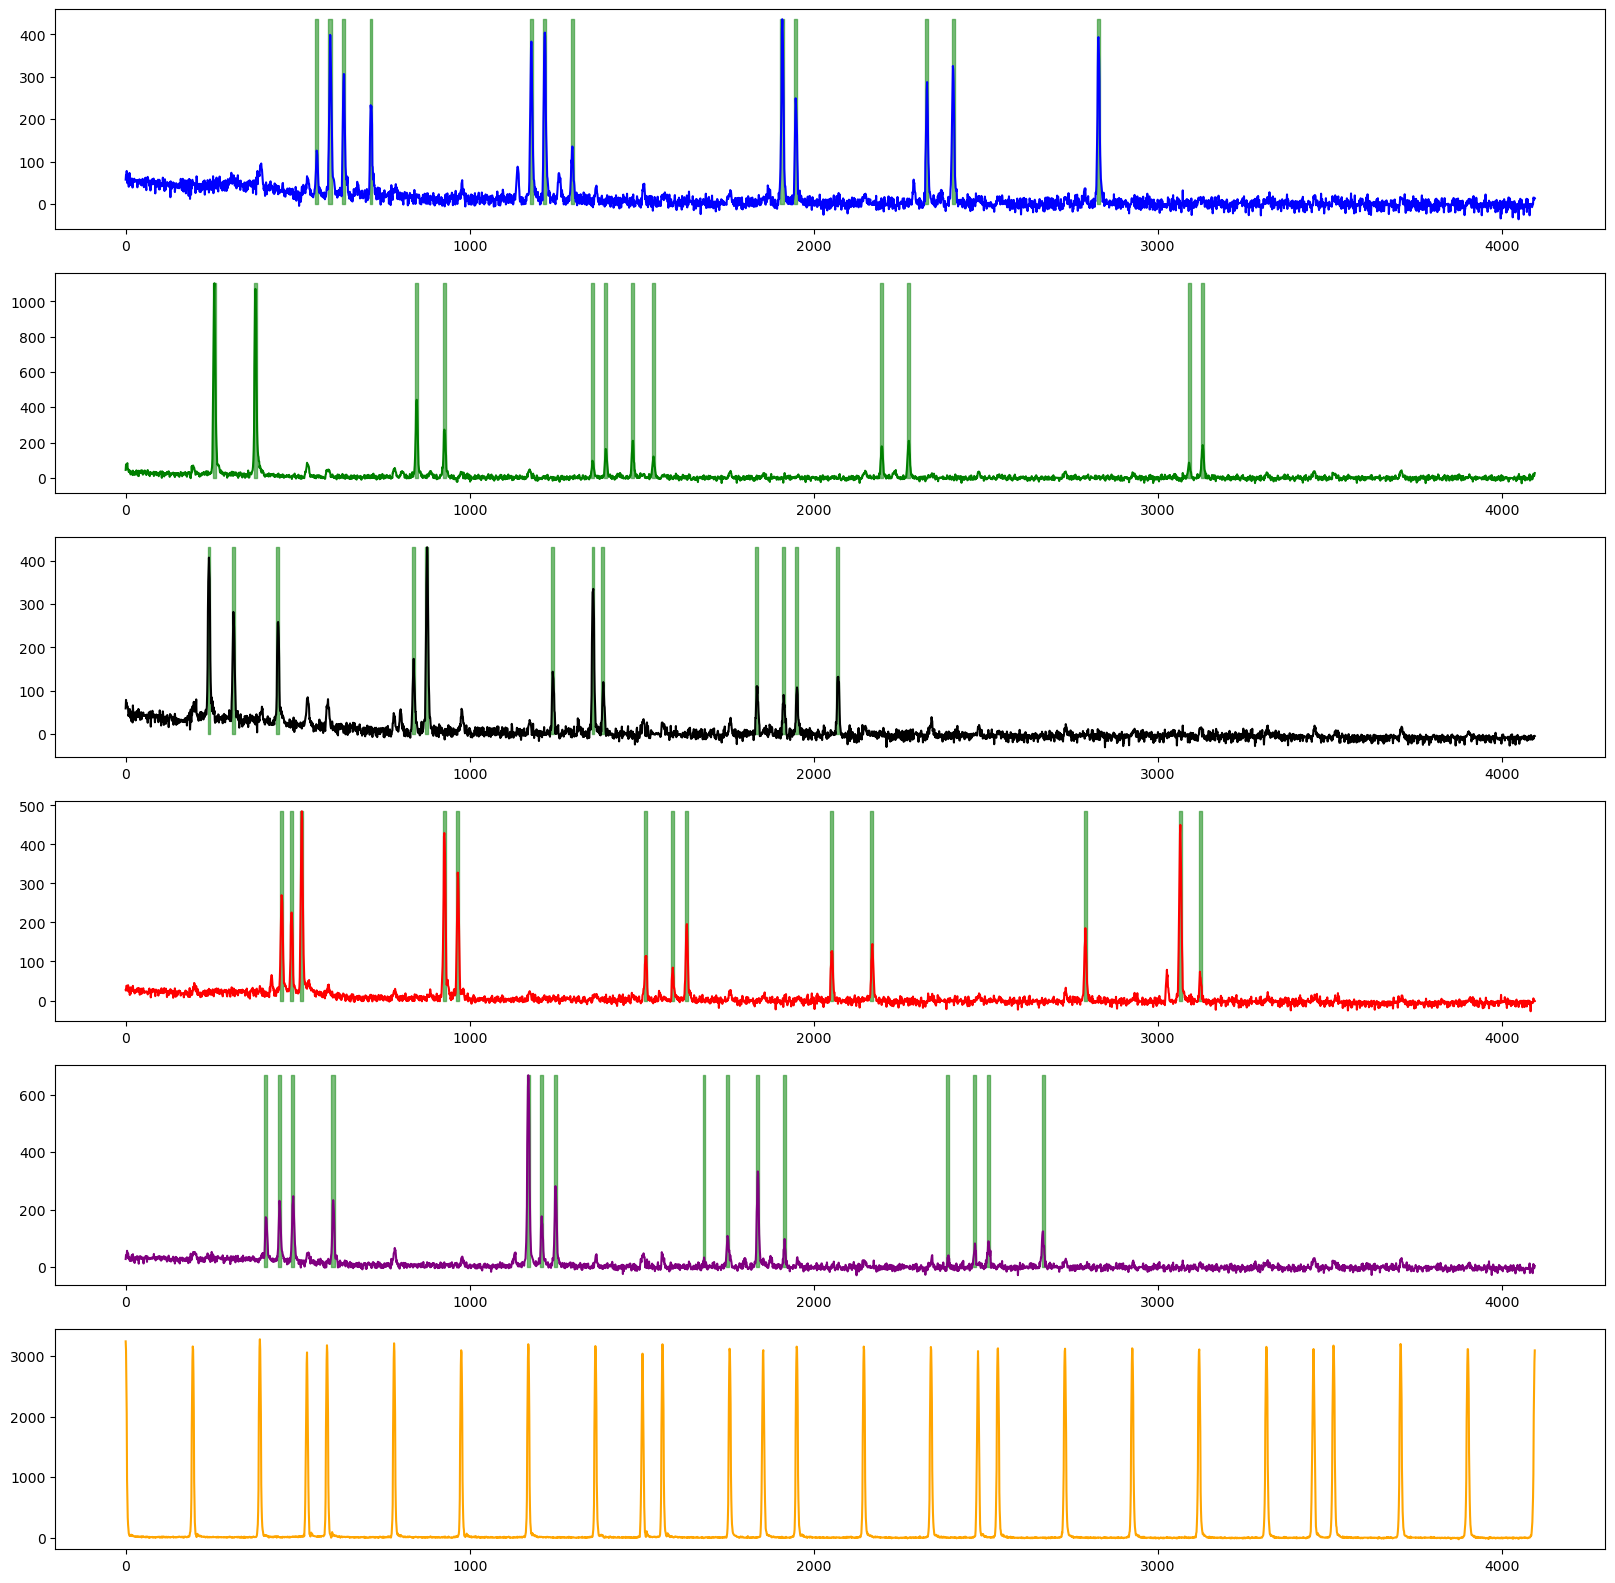

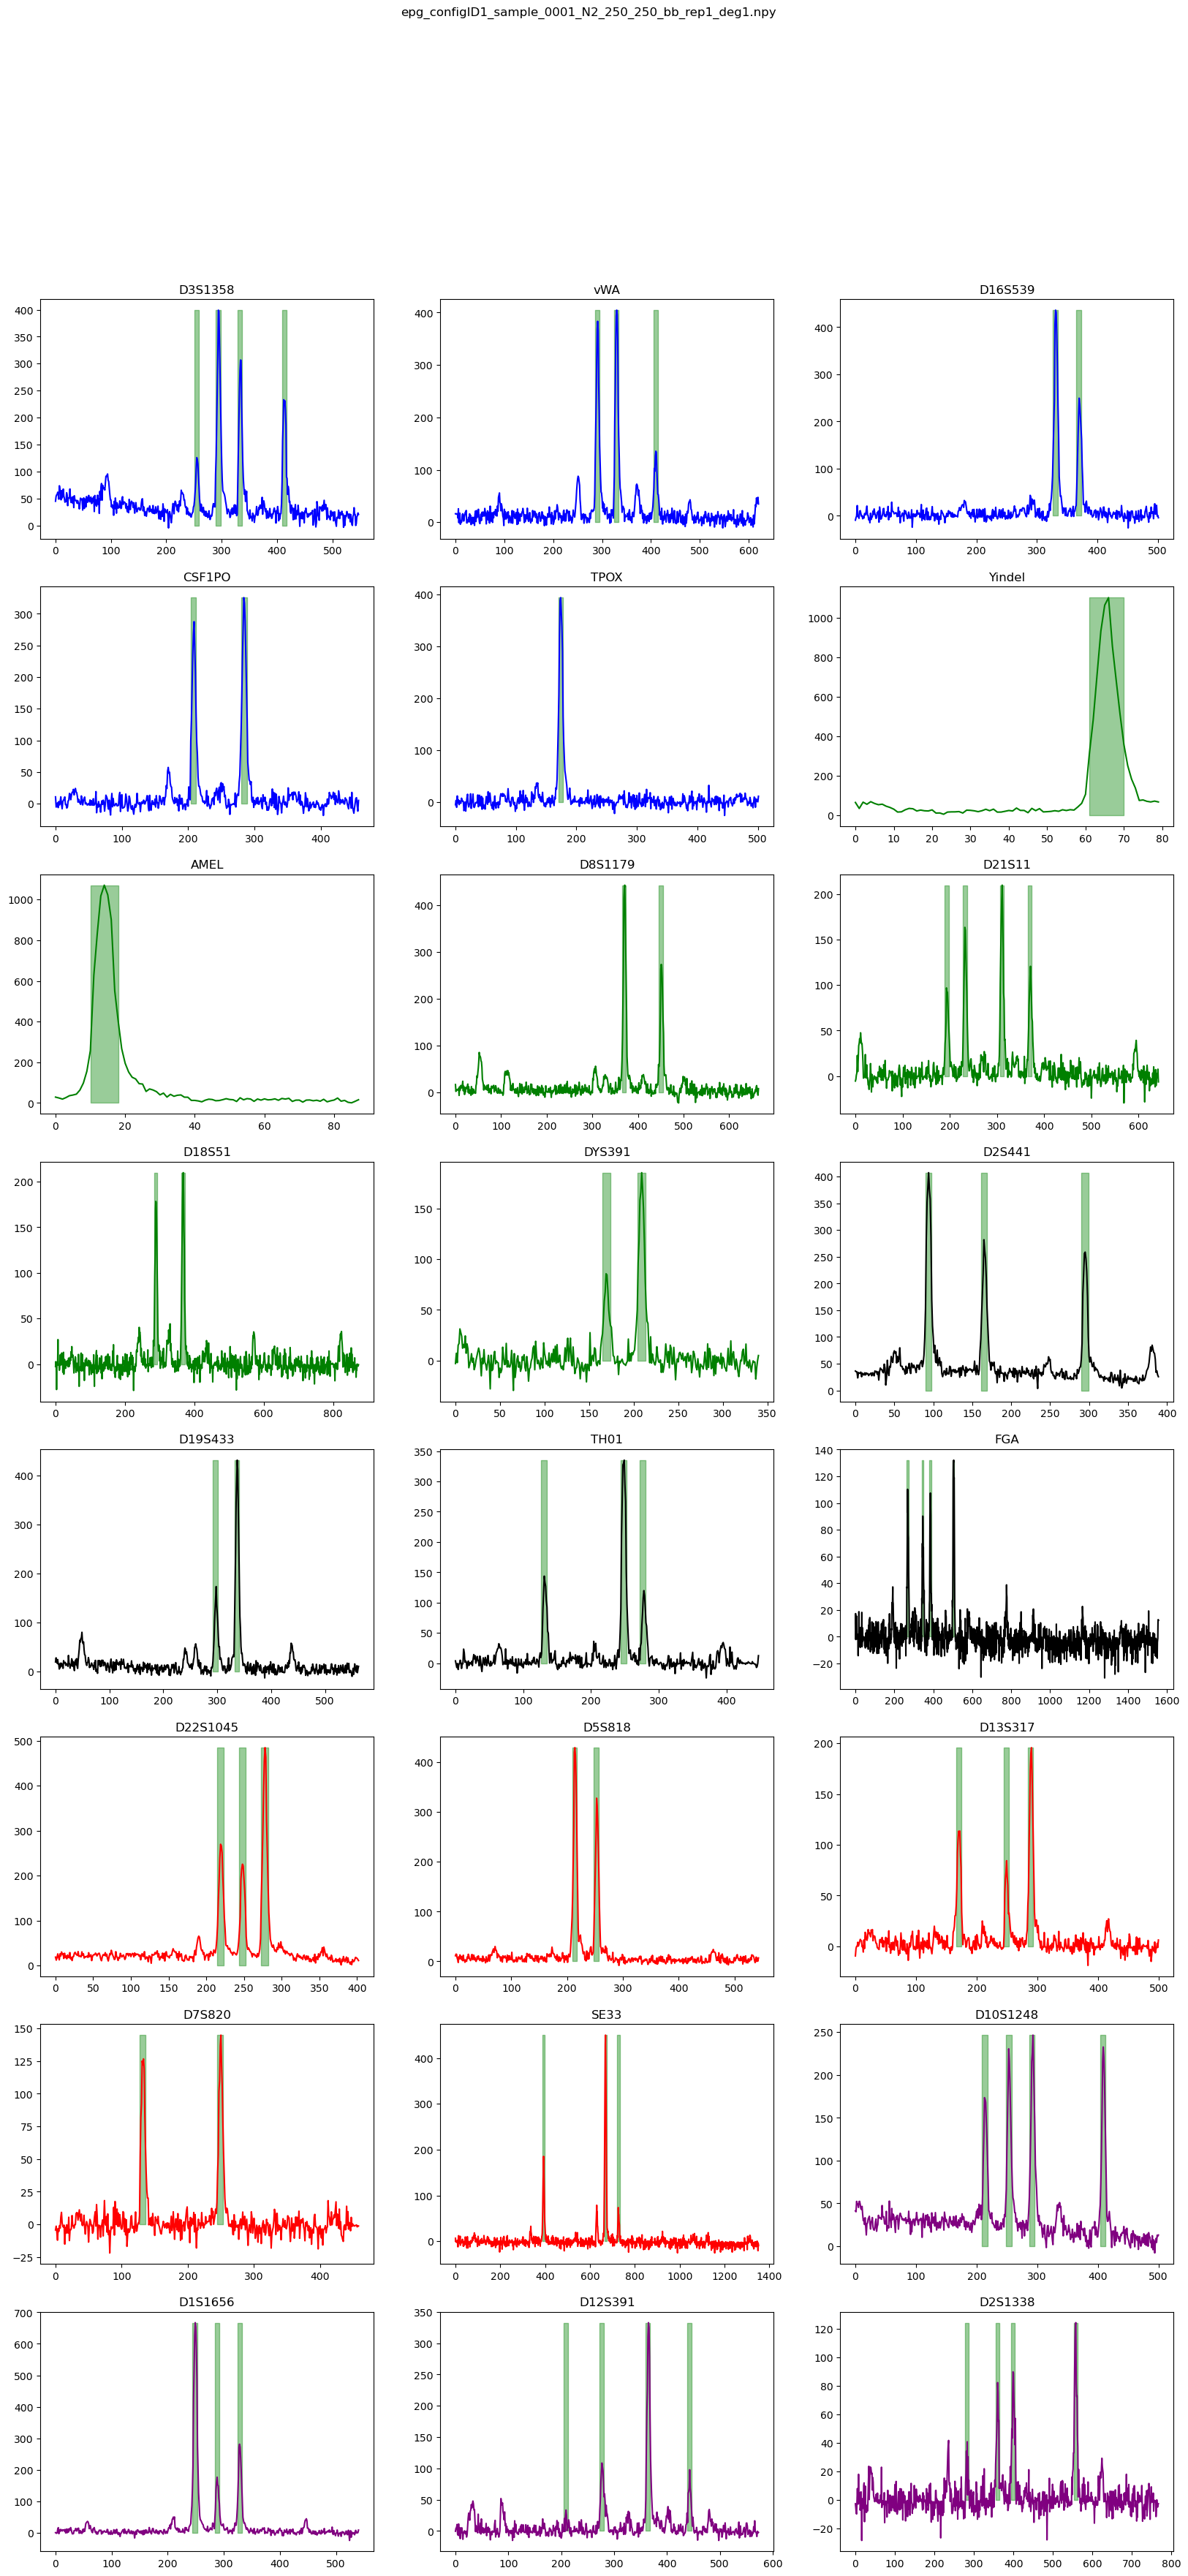

In [15]:
fig = plot_profile(hid_images=[image], title=False, return_fig=True)
# save figure
fig.savefig("figures/SynthEPG.pdf")
plot_profile_markers(hid_images=[image])

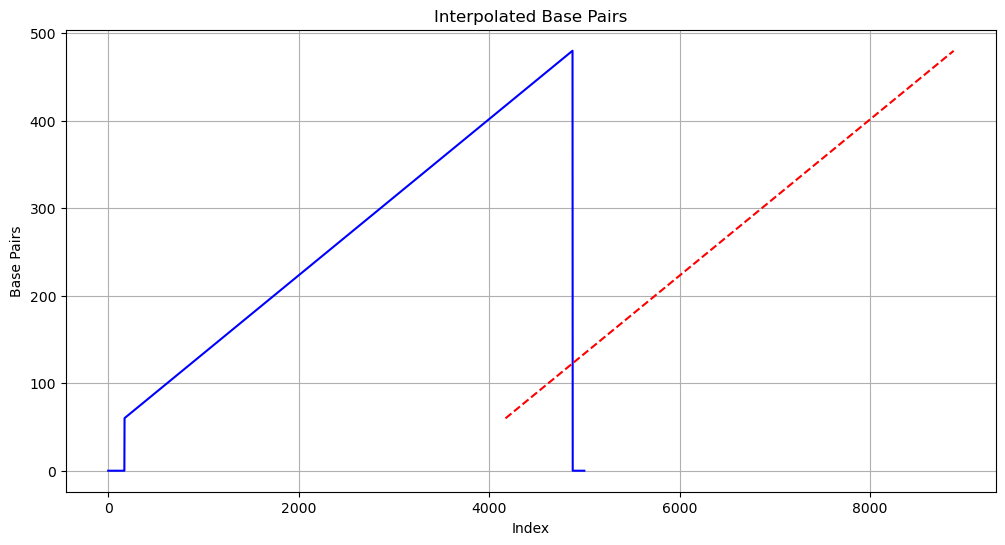

In [8]:
# plot the interpolated base pairs
plt.figure(figsize=(12, 6))
plt.plot(image.interpolated_base_pairs, color='blue')

x = np.linspace(4171, 8876, 1000)
f_x = (480 - 60) / (8876 - 4171) * x - 312.5
plt.plot(x, f_x, color='red', linestyle='--', label='Linear Fit')

plt.title("Interpolated Base Pairs")
plt.xlabel("Index")
plt.ylabel("Base Pairs")
plt.grid(True)
plt.show()

In [9]:
ibp = image.interpolated_base_pairs
ibp[4170:4172]
ibp[8876:8877]
# ibp[4171], ibp[8876], (480-60)/(9455-3700)

array([], dtype=float64)

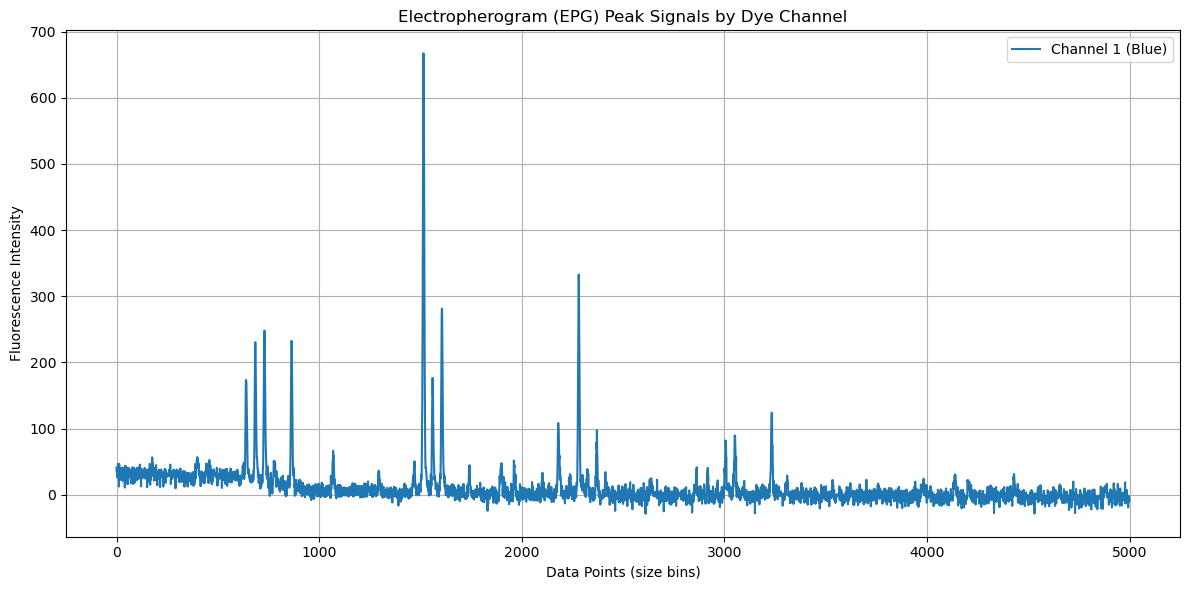

In [10]:
# epg = get_peak_data(image.path) # shape: (6, 4096)
epg = np.load(image.path)[4:5, 000:]

def plot_epg_together(epg):
    plt.figure(figsize=(12, 6))
    dye_labels = ['Blue', 'Green', 'Yellow', 'Red', 'Purple', 'Orange']  # Optional: adjust per your kit

    for i in range(epg.shape[0]):
        plt.plot(epg[i], label=f'Channel {i+1} ({dye_labels[i]})')

    plt.xlabel("Data Points (size bins)")
    plt.ylabel("Fluorescence Intensity")
    plt.title("Electropherogram (EPG) Peak Signals by Dye Channel")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_epg_together(epg)

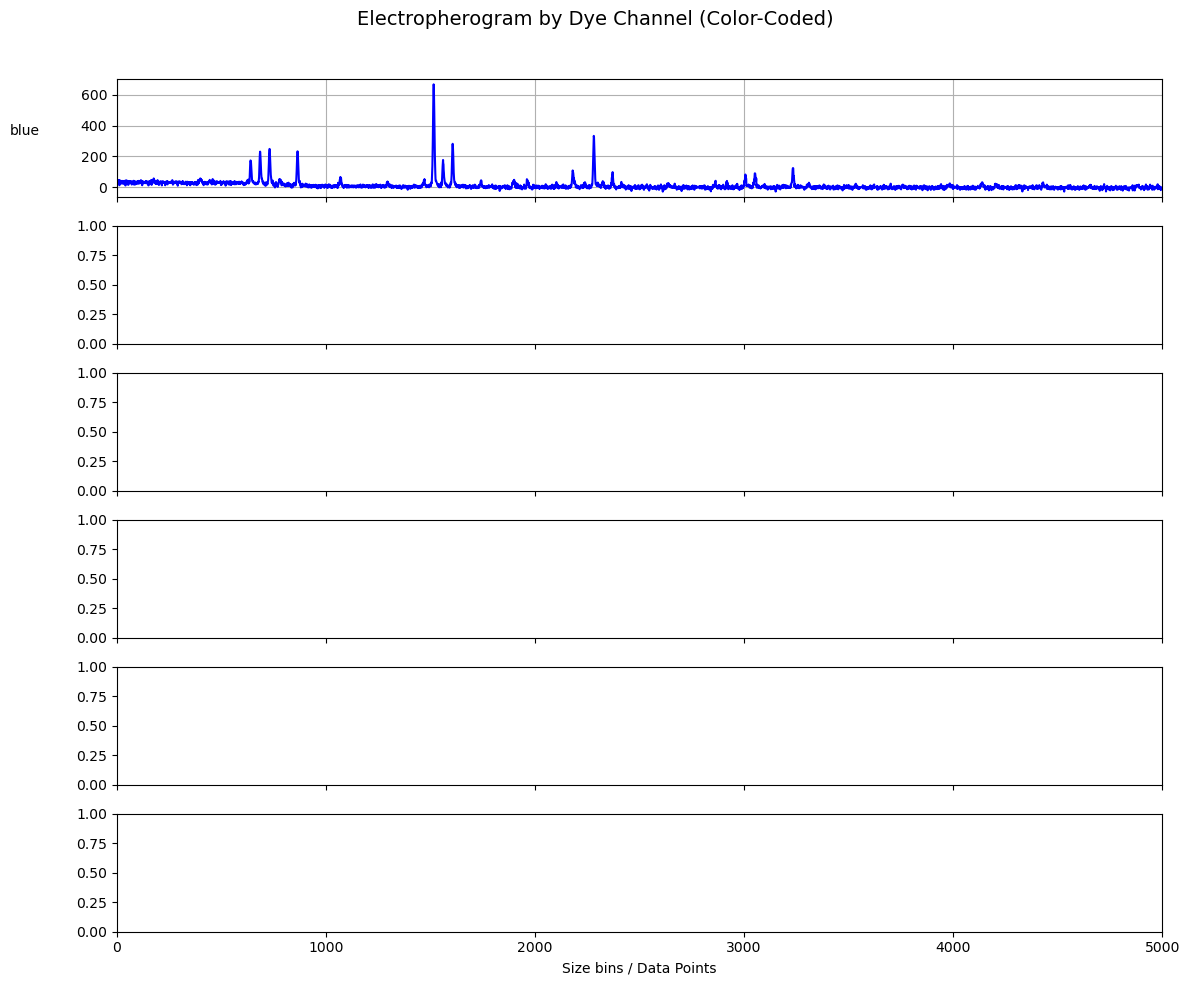

In [11]:
dye_colors = ['blue', 'green', 'gold', 'red', 'purple', 'orange']

fig, axs = plt.subplots(6, 1, figsize=(12, 10), sharex=True)

for i in range(epg.shape[0]):
    axs[i].plot(epg[i], color=dye_colors[i])
    axs[i].set_ylabel(dye_colors[i], rotation=0, labelpad=40, fontsize=10)
    axs[i].grid(True)
    axs[i].set_xlim(0, epg.shape[1])

axs[-1].set_xlabel("Size bins / Data Points")
plt.suptitle("Electropherogram by Dye Channel (Color-Coded)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
